![jupyter](img/itq-logo.png )

## Exámen Práctico - Segundo Parcial

![jupyter](img/python-logo.png )

*Lesly Noemi Becerra Campaña*

# Primera Parte (Célula Sana)

#### 0) Cargar una de las imágenes histológicas

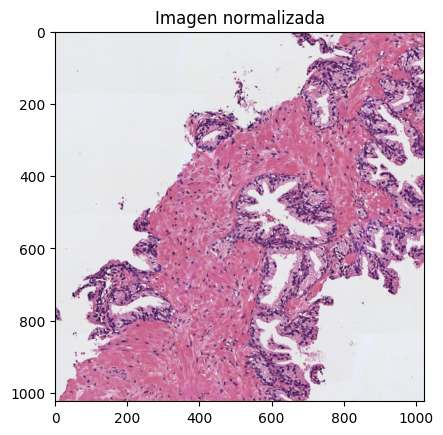

In [19]:
from skimage import io
from skimage.filters import gaussian, threshold_otsu
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.measure import regionprops, label

# Utilizar la librería skimage.io para leer la imagen 'histo_x.jpg' en formato RGB.
imagen1 = io.imread('img/histo_1.jpg')
rgb = imagen1.copy()

# Normalizar la imagen para que los píxeles se encuentren en el rango [0, 1]
img_normalizada = rgb.astype('float') / 255

# Visualizar la imagen
plt.imshow(img_normalizada)
plt.title('Imagen normalizada')
plt.show()

#### 1) Realizar una transformación de color para convertir la imagen al espacio de color CMYK

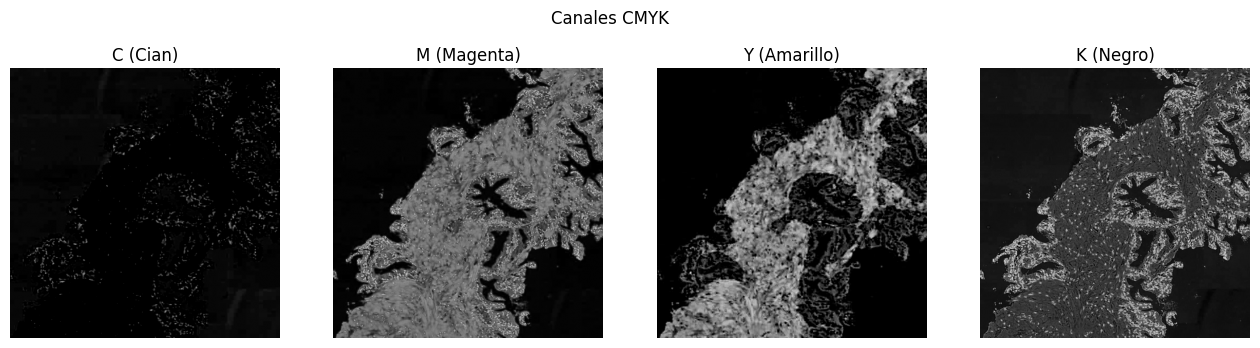

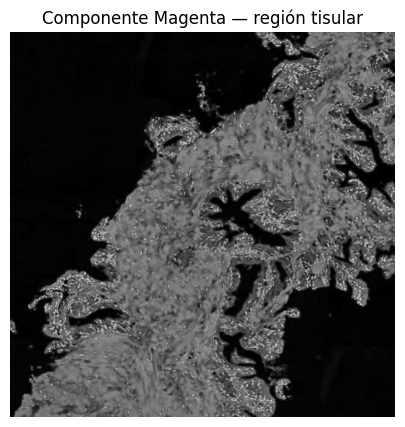

In [20]:
R = img_normalizada[:,:,0]
G = img_normalizada[:,:,1]
B = img_normalizada[:,:,2]

K = 1 - np.max(img_normalizada, axis=2)

# Calcular canales CMY (evitar división por cero con 1e-8)
C = (1 - R - K) / (1 - K + 1e-8)
M = (1 - G - K) / (1 - K + 1e-8)
Y = (1 - B - K) / (1 - K + 1e-8)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(C, cmap='gray'); axes[0].set_title('C (Cian)');   axes[0].axis('off')
axes[1].imshow(M, cmap='gray'); axes[1].set_title('M (Magenta)'); axes[1].axis('off')
axes[2].imshow(Y, cmap='gray'); axes[2].set_title('Y (Amarillo)');axes[2].axis('off')
axes[3].imshow(K, cmap='gray'); axes[3].set_title('K (Negro)');   axes[3].axis('off')

plt.suptitle('Canales CMYK')
plt.show()

# Extraer la componente magenta de la imagen (que corresponde a la región tisular)
Magenta = M
# Visualizar la imagen del canal magenta
plt.figure(figsize=(6, 5))
plt.imshow(Magenta, cmap='gray')
plt.title('Componente Magenta — región tisular')
plt.axis('off')
plt.show()

#### 2) Umbralizar la imagen para separar los píxeles del fondo de la región tisular

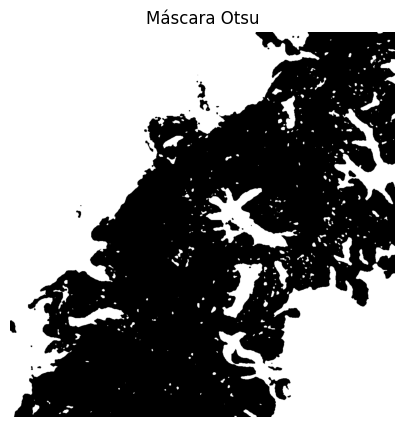

Umbral de Otsu: 55


In [21]:
# Aplicar un filtro gaussiano de tamaño 5x5 y después utilizar el método de Otsu de manera que
# los píxeles correspondientes al lumen y al background de la imagen sean 1(blanco) y el resto de los píxeles tengan un valor de 0(negro).
# Nota: Recordar que el método de Otsu requiere como input una imagen en el rango [0-255] en formato "uint8".
Magenta_suavizada = gaussian(Magenta, sigma=1.4)

# Convertir a uint8 para Otsu
Magenta_uint8 = (Magenta_suavizada * 255).astype('uint8')

# Umbral de Otsu
umbral = threshold_otsu(Magenta_uint8)

# Los píxeles de lumen y background (claros) = 0, tejido (oscuro) = 1
mascara_otsu = (Magenta_uint8 < umbral).astype('uint8')

# Visualizar la máscara resultante
plt.figure(figsize=(6, 5))
plt.imshow(mascara_otsu, cmap='gray')
plt.title('Máscara Otsu')
plt.axis('off')
plt.show()

print(f'Umbral de Otsu: {umbral}')

#### 3) Limpiar la imagen eliminando los artefactos de lumen (objetos blancos pequeños que no son lúmenes)

(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

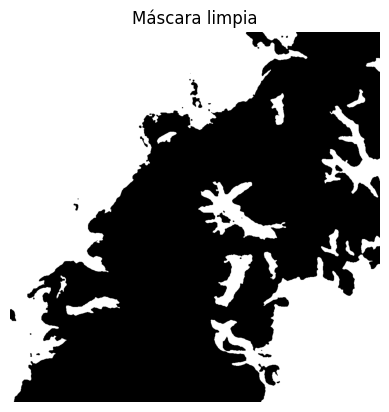

In [22]:
# Utilizar la librería skimage.morphology.remove_small_objects para eliminar aquellos objetos cuya área sea menor a 300 píxeles
# Más información en https://scikit-image.org/docs/dev/api/skimage.morphology.html#skimage.morphology.remove_small_objects
from skimage.morphology import remove_small_objects

# Eliminar objetos pequeños (<300 píxeles)
mascara_limpia = remove_small_objects(mascara_otsu.astype(bool), max_size=300)

# Visualizaer la máscara resultante
plt.imshow(mascara_limpia, cmap='gray')
plt.title("Máscara limpia")
plt.axis('off')

#### 4) Rellenar con 0s el fondo de la imagen para quedarnos únicamente con los lúmenes

(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

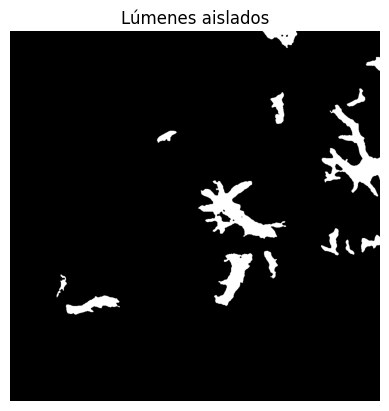

In [23]:
# Aplicar el algoritmo de expansión a partir de semillas (region growing) de manera que únicamente los lúmenes sean blancos
# y el resto de la imagen negra. Pista: utilizar dos semillas. Nota: Se pueden fijar las semillas de manera manual, pero
# se valorará positivamente a aquell@s que desarrollen una función para encontrarlas automáticamente.
from skimage.segmentation import flood

# Crear máscara vacía
mascara_lumenes = mascara_limpia.astype(bool)

# Crear máscara de fondo vacía
fondo = np.zeros_like(mascara_lumenes, dtype=bool)

# Semillas automáticas en las 4 esquinas para cubrir todo el fondo
seeds = [(0, 0), (0, -1), (-1, 0), (-1, -1)]

for seed in seeds:
    fondo = fondo | flood(mascara_lumenes, seed_point=seed, connectivity=1)

# Invertir → quedarnos solo con lúmenes
mascara_lumenes = mascara_lumenes & (~fondo)

# Visualizar la máscara resultante
plt.imshow(mascara_lumenes, cmap='gray')
plt.title("Lúmenes aislados")
plt.axis('off')

#### 5) Rellenar los objetos de los lúmenes

(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

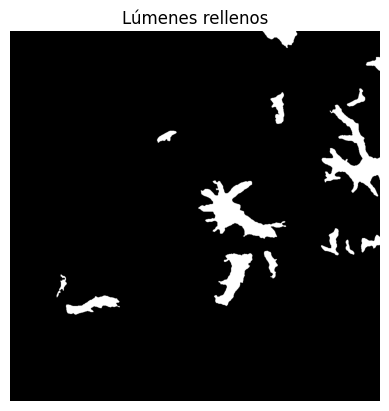

In [24]:
# Rellenar los lúmenes con la función binary_fill_holes de la librería scipy.ndimage.morphology
from scipy.ndimage import binary_fill_holes

mascara_rellena = binary_fill_holes(mascara_lumenes)

# Visualizar la máscara resultante
plt.imshow(mascara_rellena, cmap='gray')
plt.title("Lúmenes rellenos")
plt.axis('off')

#### 6) Detectar y dibujar los contornos de los lúmenes sobre la imagen original

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

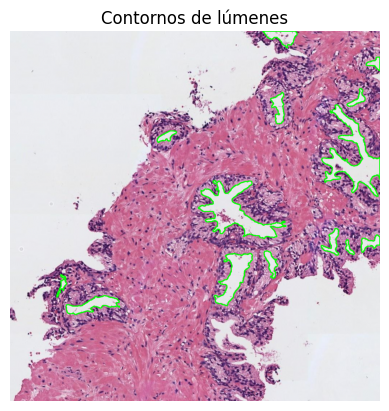

In [25]:
# Dibujar los contornos de los lúmenes en color verde sobre la imagen original RGB. Nota: Utilizar los flags necesarios
# para que los contornos en verde sean perfectamente visibles. 

# Convertir a uint8
mascara_uint8 = (mascara_rellena * 255).astype(np.uint8)

# Encontrar contornos
contornos, _ = cv2.findContours(mascara_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Copia de la imagen original
img_contornos = img_normalizada.copy()

# Dibujar contornos
cv2.drawContours(img_contornos, contornos, -1, (0,255,0), 2)

# Visualizar la imagen superpuesta
plt.imshow(img_contornos)
plt.title("Contornos de lúmenes")
plt.axis('off')

#### 7) Identificar y cropear el lumen más grande

(np.float64(-0.5), np.float64(242.5), np.float64(161.5), np.float64(-0.5))

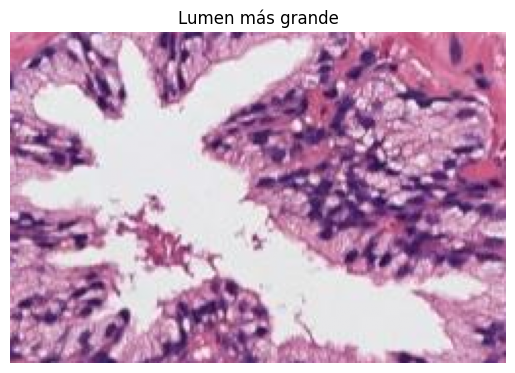

In [26]:
# Determinar cuál es el lumen de mayor área y hacer un crop del mismo sobre la imagen original RGB.
# Encontrar el mayor contorno
max_contorno = max(contornos, key=cv2.contourArea)

# Bounding box
x, y, w, h = cv2.boundingRect(max_contorno)

# Crop
lumen_crop = img_normalizada[y:y+h, x:x+w]

# Visualizar el lumen cropeado.
plt.imshow(lumen_crop)
plt.title("Lumen más grande")
plt.axis('off')

#### 8) Extraer 13 características geométricas que permitan caracterizar el lumen recortado 

In [ ]:
# Calcular las siguientes características del crop del lumen de mayor área, redondeando su valor hasta el cuarto decimal.
# 1) Área
# 2) Área de la bounding box
# 3) Área convexa
# 4) Exentricidad
# 5) Diámetro equivalente
# 6) Extensión
# 7) Diámetro Feret
# 8) Longitud del eje mayor
# 9) Longitud del eje menor
# 10) Orientación
# 11) Perímetro
# 12) Solidez
# 13) Compacidad

In [56]:
# Etiquetar
label_img = label(mascara_rellena)

# Obtener regiones
props = regionprops(label_img)

# Región más grande
region = max(props, key=lambda x: x.area)

# Características
area = round(region.area, 4)
boundingbox_area = round(region.bbox_area, 4)
convexa_area = round(region.convex_area, 4)
exentricidad = round(region.eccentricity, 4)
equivalente_diametro = round(region.equivalent_diameter, 4)
extension = round(region.extent, 4)
feret_diametro = round(region.feret_diameter_max, 4)
eje_mayor = round(region.major_axis_length, 4)
eje_menor = round(region.minor_axis_length, 4)
orientacion = round(region.orientation, 4)
perimetro = round(region.perimeter, 4)
solidez = round(region.solidity, 4)

# Compacidad (corregido)
compacidad = round((perimetro ** 2) / (4 * np.pi * area), 4)

print("Área:", area)
print("Área bbox:", boundingbox_area)
print("Área convexa:", convexa_area)
print("Excentricidad:", exentricidad)
print("Diámetro equivalente:", equivalente_diametro)
print("Extensión:", extension)
print("Diametro Feret:", feret_diametro)
print("Eje mayor:", eje_mayor)
print("Eje menor:", eje_menor)
print("Orientación:", orientacion)
print("Perímetro:", perimetro)
print("Solidez:", solidez)
print("Compacidad:", compacidad)

Área: 13992.0
Área bbox: 39366.0
Área convexa: 28898.0
Excentricidad: 0.8471
Diámetro equivalente: 133.4735
Extensión: 0.3554
Diametro Feret: 256.3123
Eje mayor: 237.5941
Eje menor: 126.2534
Orientación: 1.0024
Perímetro: 1198.0052
Solidez: 0.4842
Compacidad: 8.1626


C:\Users\HP\AppData\Local\Temp\ipykernel_10516\1016417136.py:12: FutureWarning: `RegionProperties.bbox_area` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.area_bbox` instead. 
  boundingbox_area = round(region.bbox_area, 4)
C:\Users\HP\AppData\Local\Temp\ipykernel_10516\1016417136.py:13: FutureWarning: `RegionProperties.convex_area` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.area_convex` instead. 
  convexa_area = round(region.convex_area, 4)
C:\Users\HP\AppData\Local\Temp\ipykernel_10516\1016417136.py:15: FutureWarning: `RegionProperties.equivalent_diameter` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.equivalent_diameter_area` instead. 
  equivalente_diametro = round(region.equivalent_diameter, 4)
C:\Users\HP\AppData\Local\Temp\ipykernel_10516\1016417136.py:18: FutureWarning: `RegionProperties.major_axis_length` is deprecated sta

# Segunda Parte (Célula Cancerigena)

#### 0) Cargar una de las imágenes histológicas

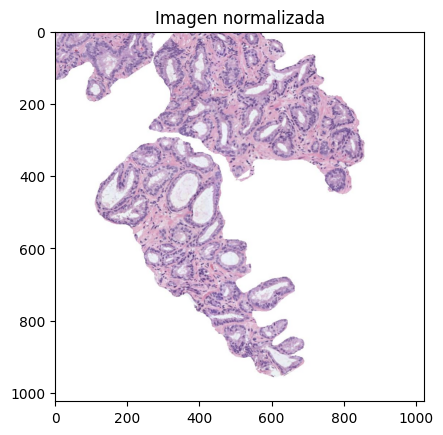

In [32]:
# Utilizar la librería skimage.io para leer la imagen 'histo_x.jpg' en formato RGB.
imagen2 = io.imread('img/histo_2.jpg')
rgb2 = imagen2.copy()

# Normalizar la imagen para que los píxeles se encuentren en el rango [0, 1]
img2_normalizada = rgb2.astype('float') / 255

# Visualizar la imagen
plt.imshow(img2_normalizada)
plt.title('Imagen normalizada')
plt.show()

#### 1) Realizar una transformación de color para convertir la imagen al espacio de color CMYK

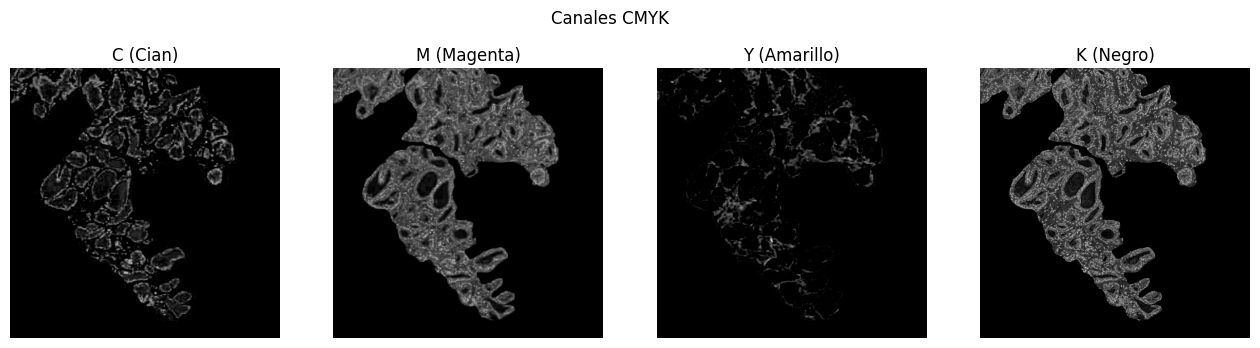

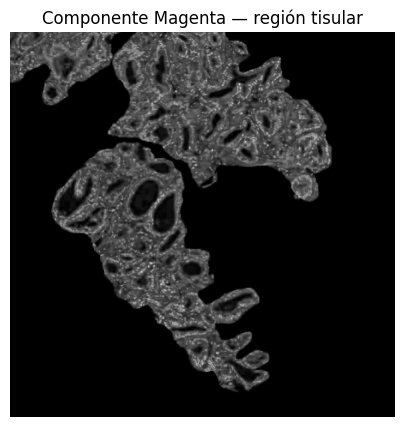

In [34]:
R2 = img2_normalizada[:,:,0]
G2 = img2_normalizada[:,:,1]
B2 = img2_normalizada[:,:,2]

K2 = 1 - np.max(img2_normalizada, axis=2)

# Calcular canales CMY (evitar división por cero con 1e-8)
C2 = (1 - R2 - K2) / (1 - K2 + 1e-8)
M2 = (1 - G2 - K2) / (1 - K2 + 1e-8)
Y2 = (1 - B2 - K2) / (1 - K2 + 1e-8)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(C2, cmap='gray'); axes[0].set_title('C (Cian)');   axes[0].axis('off')
axes[1].imshow(M2, cmap='gray'); axes[1].set_title('M (Magenta)'); axes[1].axis('off')
axes[2].imshow(Y2, cmap='gray'); axes[2].set_title('Y (Amarillo)');axes[2].axis('off')
axes[3].imshow(K2, cmap='gray'); axes[3].set_title('K (Negro)');   axes[3].axis('off')

plt.suptitle('Canales CMYK')
plt.show()

# Extraer la componente magenta de la imagen (que corresponde a la región tisular)
Magenta2 = M2
# Visualizar la imagen del canal magenta
plt.figure(figsize=(6, 5))
plt.imshow(Magenta2, cmap='gray')
plt.title('Componente Magenta — región tisular')
plt.axis('off')
plt.show()

#### 2) Umbralizar la imagen para separar los píxeles del fondo de la región tisular

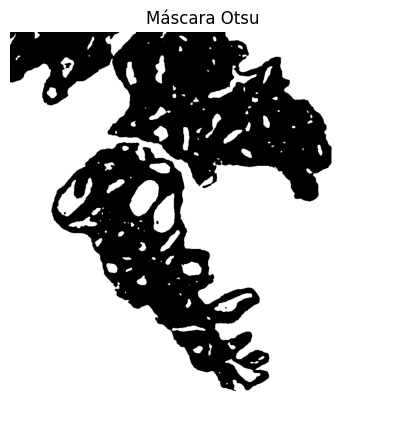

Umbral de Otsu: 27


In [35]:
# Aplicar un filtro gaussiano de tamaño 5x5 y después utilizar el método de Otsu de manera que
# los píxeles correspondientes al lumen y al background de la imagen sean 1(blanco) y el resto de los píxeles tengan un valor de 0(negro).
# Nota: Recordar que el método de Otsu requiere como input una imagen en el rango [0-255] en formato "uint8".
Magenta2_suavizada = gaussian(Magenta2, sigma=1.4)

# Convertir a uint8 para Otsu
Magenta2_uint8 = (Magenta2_suavizada * 255).astype('uint8')

# Umbral de Otsu
umbral = threshold_otsu(Magenta2_uint8)

# Los píxeles de lumen y background (claros) = 0, tejido (oscuro) = 1
mascara2_otsu = (Magenta2_uint8 < umbral).astype('uint8')

# Visualizar la máscara resultante
plt.figure(figsize=(6, 5))
plt.imshow(mascara2_otsu, cmap='gray')
plt.title('Máscara Otsu')
plt.axis('off')
plt.show()

print(f'Umbral de Otsu: {umbral}')

#### 3) Limpiar la imagen eliminando los artefactos de lumen (objetos blancos pequeños que no son lúmenes)

(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

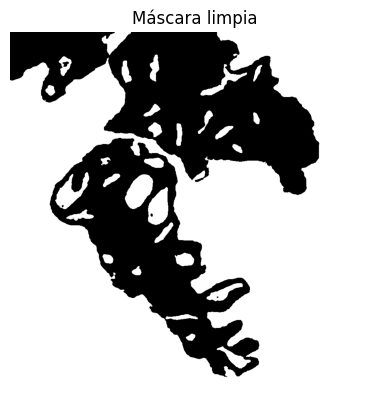

In [36]:
# Utilizar la librería skimage.morphology.remove_small_objects para eliminar aquellos objetos cuya área sea menor a 300 píxeles
# Más información en https://scikit-image.org/docs/dev/api/skimage.morphology.html#skimage.morphology.remove_small_objects
# Eliminar objetos pequeños (<300 píxeles)
mascara2_limpia = remove_small_objects(mascara2_otsu.astype(bool), max_size=300)

# Visualizaer la máscara resultante
plt.imshow(mascara2_limpia, cmap='gray')
plt.title("Máscara limpia")
plt.axis('off')

#### 4) Rellenar con 0s el fondo de la imagen para quedarnos únicamente con los lúmenes

(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

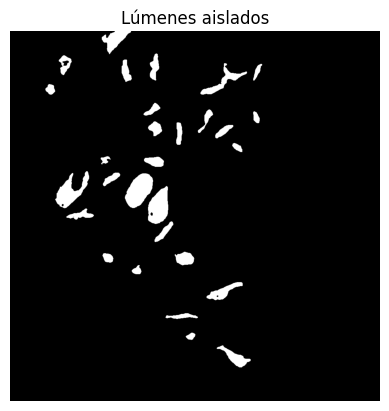

In [39]:
# Aplicar el algoritmo de expansión a partir de semillas (region growing) de manera que únicamente los lúmenes sean blancos
# y el resto de la imagen negra. Pista: utilizar dos semillas. Nota: Se pueden fijar las semillas de manera manual, pero
# se valorará positivamente a aquell@s que desarrollen una función para encontrarlas automáticamente.

# Crear máscara vacía
mascara2_lumenes = mascara2_limpia.astype(bool)

# Crear máscara de fondo vacía
fondo2 = np.zeros_like(mascara2_lumenes, dtype=bool)

# Semillas automáticas en las 4 esquinas para cubrir todo el fondo
seeds = [(0, 0), (0, -1), (-1, 0), (-1, -1)]

for seed in seeds:
    fondo2 = fondo2 | flood(mascara2_lumenes, seed_point=seed, connectivity=1)

# Invertir → quedarnos solo con lúmenes
mascara2_lumenes = mascara2_lumenes & (~fondo2)

# Visualizar la máscara resultante
plt.imshow(mascara2_lumenes, cmap='gray')
plt.title("Lúmenes aislados")
plt.axis('off')

#### 5) Rellenar los objetos de los lúmenes

(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

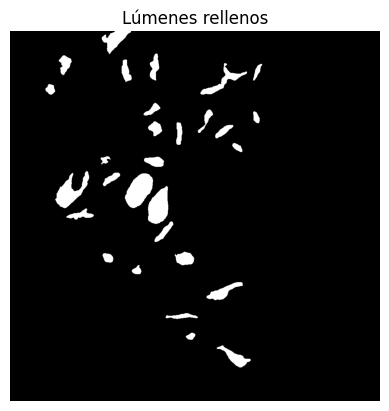

In [40]:
# Rellenar los lúmenes con la función binary_fill_holes de la librería scipy.ndimage.morphology

mascara2_rellena = binary_fill_holes(mascara2_lumenes)

# Visualizar la máscara resultante
plt.imshow(mascara2_rellena, cmap='gray')
plt.title("Lúmenes rellenos")
plt.axis('off')

#### 6) Detectar y dibujar los contornos de los lúmenes sobre la imagen original

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

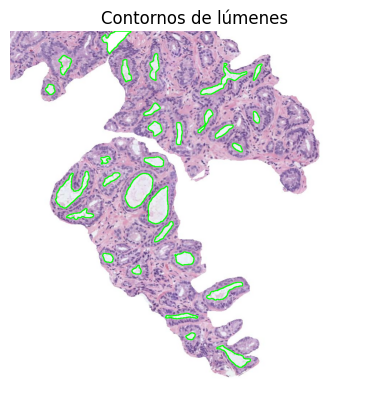

In [41]:
# Dibujar los contornos de los lúmenes en color verde sobre la imagen original RGB. Nota: Utilizar los flags necesarios
# para que los contornos en verde sean perfectamente visibles. 

# Convertir a uint8
mascara2_uint8 = (mascara2_rellena * 255).astype(np.uint8)

# Encontrar contornos
contornos2, _ = cv2.findContours(mascara2_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Copia de la imagen original
img2_contornos = img2_normalizada.copy()

# Dibujar contornos
cv2.drawContours(img2_contornos, contornos2, -1, (0,255,0), 2)

# Visualizar la imagen superpuesta
plt.imshow(img2_contornos)
plt.title("Contornos de lúmenes")
plt.axis('off')

#### 7) Identificar y cropear el lumen más grande

(np.float64(-0.5), np.float64(77.5), np.float64(95.5), np.float64(-0.5))

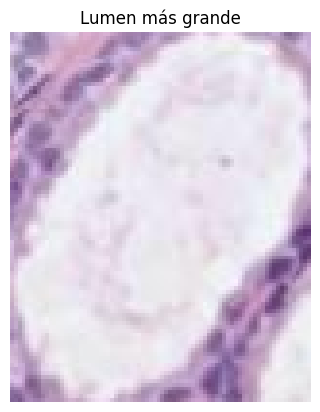

In [42]:
# Determinar cuál es el lumen de mayor área y hacer un crop del mismo sobre la imagen original RGB.
# Encontrar el mayor contorno
max2_contorno = max(contornos2, key=cv2.contourArea)

# Bounding box
x, y, w, h = cv2.boundingRect(max2_contorno)

# Crop
lumen2_crop = img2_normalizada[y:y+h, x:x+w]

# Visualizar el lumen cropeado.
plt.imshow(lumen2_crop)
plt.title("Lumen más grande")
plt.axis('off')

#### 8) Extraer 13 características geométricas que permitan caracterizar el lumen recortado 

In [43]:
# Calcular las siguientes características del crop del lumen de mayor área, redondeando su valor hasta el cuarto decimal.
# 1) Área
# 2) Área de la bounding box
# 3) Área convexa
# 4) Exentricidad
# 5) Diámetro equivalente
# 6) Extensión
# 7) Diámetro Feret
# 8) Longitud del eje mayor
# 9) Longitud del eje menor
# 10) Orientación
# 11) Perímetro
# 12) Solidez
# 13) Compacidad

In [55]:
# Etiquetar
label_img2 = label(mascara2_rellena)

# Obtener regiones
props2 = regionprops(label_img2)

# Región más grande
region2 = max(props2, key=lambda x: x.area)

# Características
area2 = round(region2.area, 4)
boundingbox_area2 = round(region2.bbox_area, 4)
convexa_area2 = round(region2.convex_area, 4)
exentricidad2 = round(region2.eccentricity, 4)
equivalente_diametro2 = round(region2.equivalent_diameter, 4)
extension2 = round(region2.extent, 4)
feret_diametro2 = round(region2.feret_diameter_max, 4)
eje_mayor2 = round(region2.major_axis_length, 4)
eje_menor2 = round(region2.minor_axis_length, 4)
orientacion2 = round(region2.orientation, 4)
perimetro2 = round(region2.perimeter, 4)
solidez2 = round(region2.solidity, 4)

# Compacidad (corregido)
compacidad2 = round((perimetro2 ** 2) / (4 * np.pi * area2), 4)

print("Área:", area2)
print("Área bbox:", boundingbox_area2)
print("Área convexa:", convexa_area2)
print("Excentricidad:", exentricidad2)
print("Diámetro equivalente:", equivalente_diametro2)
print("Extensión:", extension2)
print("Diametro Feret:", feret_diametro2)
print("Eje mayor:", eje_mayor2)
print("Eje menor:", eje_menor2)
print("Orientación:", orientacion2)
print("Perímetro:", perimetro2)
print("Solidez:", solidez2)
print("Compacidad:", compacidad2)

Área: 4839.0
Área bbox: 7488.0
Área convexa: 4973.0
Excentricidad: 0.8357
Diámetro equivalente: 78.4934
Extensión: 0.6462
Diametro Feret: 105.1903
Eje mayor: 106.1643
Eje menor: 58.3012
Orientación: -0.5603
Perímetro: 279.8061
Solidez: 0.9731
Compacidad: 1.2875


C:\Users\HP\AppData\Local\Temp\ipykernel_10516\1990953796.py:12: FutureWarning: `RegionProperties.bbox_area` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.area_bbox` instead. 
  boundingbox_area2 = round(region2.bbox_area, 4)
C:\Users\HP\AppData\Local\Temp\ipykernel_10516\1990953796.py:13: FutureWarning: `RegionProperties.convex_area` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.area_convex` instead. 
  convexa_area2 = round(region2.convex_area, 4)
C:\Users\HP\AppData\Local\Temp\ipykernel_10516\1990953796.py:15: FutureWarning: `RegionProperties.equivalent_diameter` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.equivalent_diameter_area` instead. 
  equivalente_diametro2 = round(region2.equivalent_diameter, 4)
C:\Users\HP\AppData\Local\Temp\ipykernel_10516\1990953796.py:18: FutureWarning: `RegionProperties.major_axis_length` is deprecat

## GitHub

Link: https://github.com/LeslyBc/examenPractico_P2.git